LABORATORIO FINALE
CONSOLIDAMENTO E REGOLARIZZAZIONE SU DATASET

In [ ]:

Analisi Avanzata della Regolarizzazione: Dataset Sintetico ad Alta Dimensionalità
In questo studio, non utilizzeremo dati reali ma genereremo un dataset sintetico con un elevato rapporto segnale/rumore. 
    
**Obiettivo:** Dimostrare come le architetture robuste (Dropout, L2, Batch Normalization) riescano a ignorare le feature irrilevanti rispetto a una Baseline standard.


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization, Activation
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

Configurazioni grafiche (per grafici futuri)

In [57]:
#generazione tema per seaborn e matplotlib
sns.set_theme(style="whitegrid") #sfondo bianco griglia grigia
plt.rcParams["figure.figsize"] = (12, 6) #impostazioni globali matplotlib, dimensione delle figure (larghezza=12, altezza=6)
%matplotlib inline 
#il grafico viene visualizzato direttamente nel notebook, invece di aprire una finestra separata
#%matplotlib funziona solo in ambienti come Jupyter, non fa parte di Python, quindi da errore se lo eseguo in .py normale

### Generazione e Analisi del Dataset (EDA)

#Creiamo un dataset con 100 variabili. Solo 15 variabili hanno un impatto reale sul target. Aggiungiamo un rumore gaussiano significativo ($noise=25$) per simulare dati sporchi.

In [59]:
#make_regression è una funzione di sklearn che genera un dataset sintetico per problemi di regressione.
#genero un dataset con 6000 campioni (X) e 100 feature (y), di cui solo 15 sono informative, con un rumore di 25

#noise 25.0 è un parametro che aggiunge rumore gaussiano ai dati, rendendo il problema di regressione più realistico e sfidante.
#praticamente aggiunge rumore ai dati che va da -25 a 25, media 0 e deviazione standard 25

#il rumore non è necessariamente 'errore' ma può rappresentare fattori non osservati dalle feature, errori di misura, variabilità reale nei dati, o semplicemente la complessità intrinseca del problema di regressione.
#esempio: voglio prevedere i tempi di consegna di una pacco, ho fornitore, quantità e nazione, ma non ho traffico, scioperi, meteo, ferie, ecc, tutti quei dati finiscono nel rumore
#quind il rumore simula l'imperefezione/l'inprevedibilità del mondo reale, e il machine learning vero non consiste nel trovare la formula perfetta, ma nel trovare una relazione utile nonostante il rumore.

X, y = make_regression(
    n_samples=6000, #6000 campioni
    n_features=100, #100 feature
    n_informative=15, 
    noise=25.0, 
    random_state=42
)
#Normalizzo il target

#Normalmente, in un problema di regressione, non è necessario normalizzare il target (y) perchè stiamo cercando di prevedere valori continui, e il target non influisce direttamente sulla convergenza del modello come accade nelle reti neurali per classificazione. Tuttavia, in alcuni casi, specialmente quando il target ha una scala molto ampia o è molto variabile, normalizzare il target può aiutare a stabilizzare l'addestamento e migliorare le prestazioni del modello. In questo caso, dato che stiamo generando un dataset sintetico con rumore, potrebbe essere utile normalizzare il target per facilitare l'apprendimento del modello.
#standardscaler richiede dati in formato 2D, quindi devo rimodellare y da (6000,) a (6000,1) con reshape (-1,1) e poi rimetterlo in forma originale con revel() dopo la normalizzazione

#normalizziamo il target per velocizzare la convergenza del modello
#scaler = StandardScaler() 
#y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

#standarizzazione manuale:
y=(y-y.mean())/y.std()
    
feature_names = [f'Feat_{i}' for i in range(100)]
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
    
print(f"Dimensioni del Dataset: {df.shape}")
display(df.iloc[:, :10].describe()) # Mostro solo le prime 10 feature (per brevità), noto che deviazione standard è 1 e media 0, come previsto dalla creazoine del dataset con make_regression
display(df.iloc[:,-1].describe()) #descrivo il target scalato, noto deviazione standard 1 e media 0, come previsto dallo standard scaler


Dimensioni del Dataset: (6000, 101)


,Feat_0,Feat_1,Feat_2,Feat_3,Feat_4,Feat_5,Feat_6,Feat_7,Feat_8,Feat_9
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.002112,-0.001749,-0.005200,-0.000749,0.014843,0.032045,-0.034638,-0.015766,-0.015211,0.005868
std,0.982843,1.011354,1.003088,0.997920,1.004975,1.002629,1.003460,1.013533,1.009901,0.990961
min,-3.347473,-3.453354,-3.729174,-3.856375,-3.604870,-3.426983,-4.374043,-3.616800,-3.587377,-3.436062
25%,-0.671431,-0.668450,-0.681344,-0.675612,-0.656688,-0.643845,-0.714116,-0.692835,-0.710187,-0.673598
50%,0.014702,0.004162,-0.007745,-0.023095,0.021079,0.035526,-0.040139,-0.010329,-0.009950,0.013973
75%,0.657554,0.661882,0.687487,0.675254,0.688718,0.698818,0.654094,0.667209,0.667244,0.665098
max,3.609479,3.383526,3.766234,4.202026,3.671569,3.650444,3.703406,3.627253,3.548682,3.520649


count    6.000000e+03
mean    -3.552714e-18
std      1.000083e+00
min     -3.562856e+00
25%     -6.817157e-01
50%      1.319583e-02
75%      6.655524e-01
max      3.371597e+00
Name: Target, dtype: float64

#### Visualizzazione delle Correlazioni

Noto che molte feature hanno correlazione quasi nulla con il Target: queste sono le feature 'rumore' che il modello robusto dovrà imparare a ignorare.

In [60]:
#seleziono le colonne (feature) che hanno una correlazione più alta con il target, in questo modo riduco la dimensionalità del dataset e rimuovo le feature meno rilevanti, che potrebbero introdurre rumore e rendere più difficile l'apprendimento del modello. Inoltre, ridurre il rumore e la dimensionalità del dataset può aiutare a prevenire l'overfitting, migliorare la generalizzazione del modello e velocizzare l'addestramento. 
# In questo caso, seleziono le prime 20 feature

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#1- Calcolo la matrice di correlazione rispetto al target
#(l'ultima colonna è il target)
target_col=df.columns[-1]

#calcolo la matrice di correlazione
#correlation_matrix=df.corr()[target_col].abs().sort_values(ascending=False)
correlations=df.corr() #creo la matrice di correlazione di tutto il dataset, anche se a me  interessa solo la colonna del target
correlations=correlations[target_col].abs().sort_values(ascending=False) #seleziono solo la colonna del target e ordino in base alla correlazione assoluta

top_10_features=correlations.iloc[1:11].index.tolist() #seleziono le prime 10 feature più correlate, escludendo il target stesso che ha correlazione 1 con se stesso
 #mostro l'ordine delle feature in base alla correlazione con il target
print("Top 10 feature più correlate con il target:")
for i, feature in enumerate(top_10_features, start=1):
    print(f"{i}. {feature} - Correlazione: {correlations[feature]:.4f}") 
cols_to_plot=top_10_features + [target_col] #seleziono le colonne da plottare, le 10 feature più correlate e il target


Top 10 feature più correlate con il target:
1. Feat_6 - Correlazione: 0.3784
2. Feat_44 - Correlazione: 0.3781
3. Feat_0 - Correlazione: 0.3710
4. Feat_80 - Correlazione: 0.3329
5. Feat_94 - Correlazione: 0.3300
6. Feat_62 - Correlazione: 0.3067
7. Feat_76 - Correlazione: 0.2950
8. Feat_25 - Correlazione: 0.2611
9. Feat_48 - Correlazione: 0.2361
10. Feat_17 - Correlazione: 0.1755


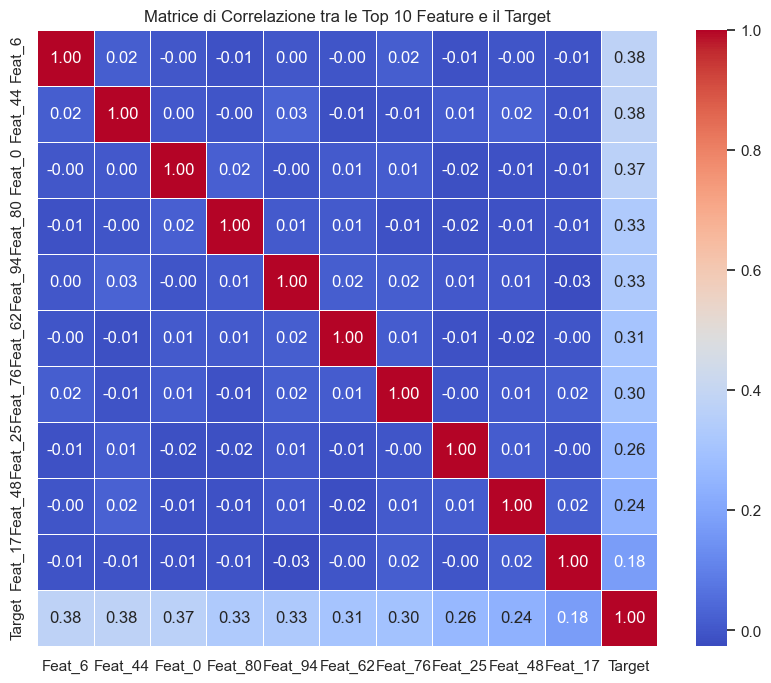

In [61]:
#2- Visualizzo la matrice di correlazione con una HEATMAP
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title(f"Matrice di Correlazione tra le Top 10 Feature e il {target_col}")
plt.show()

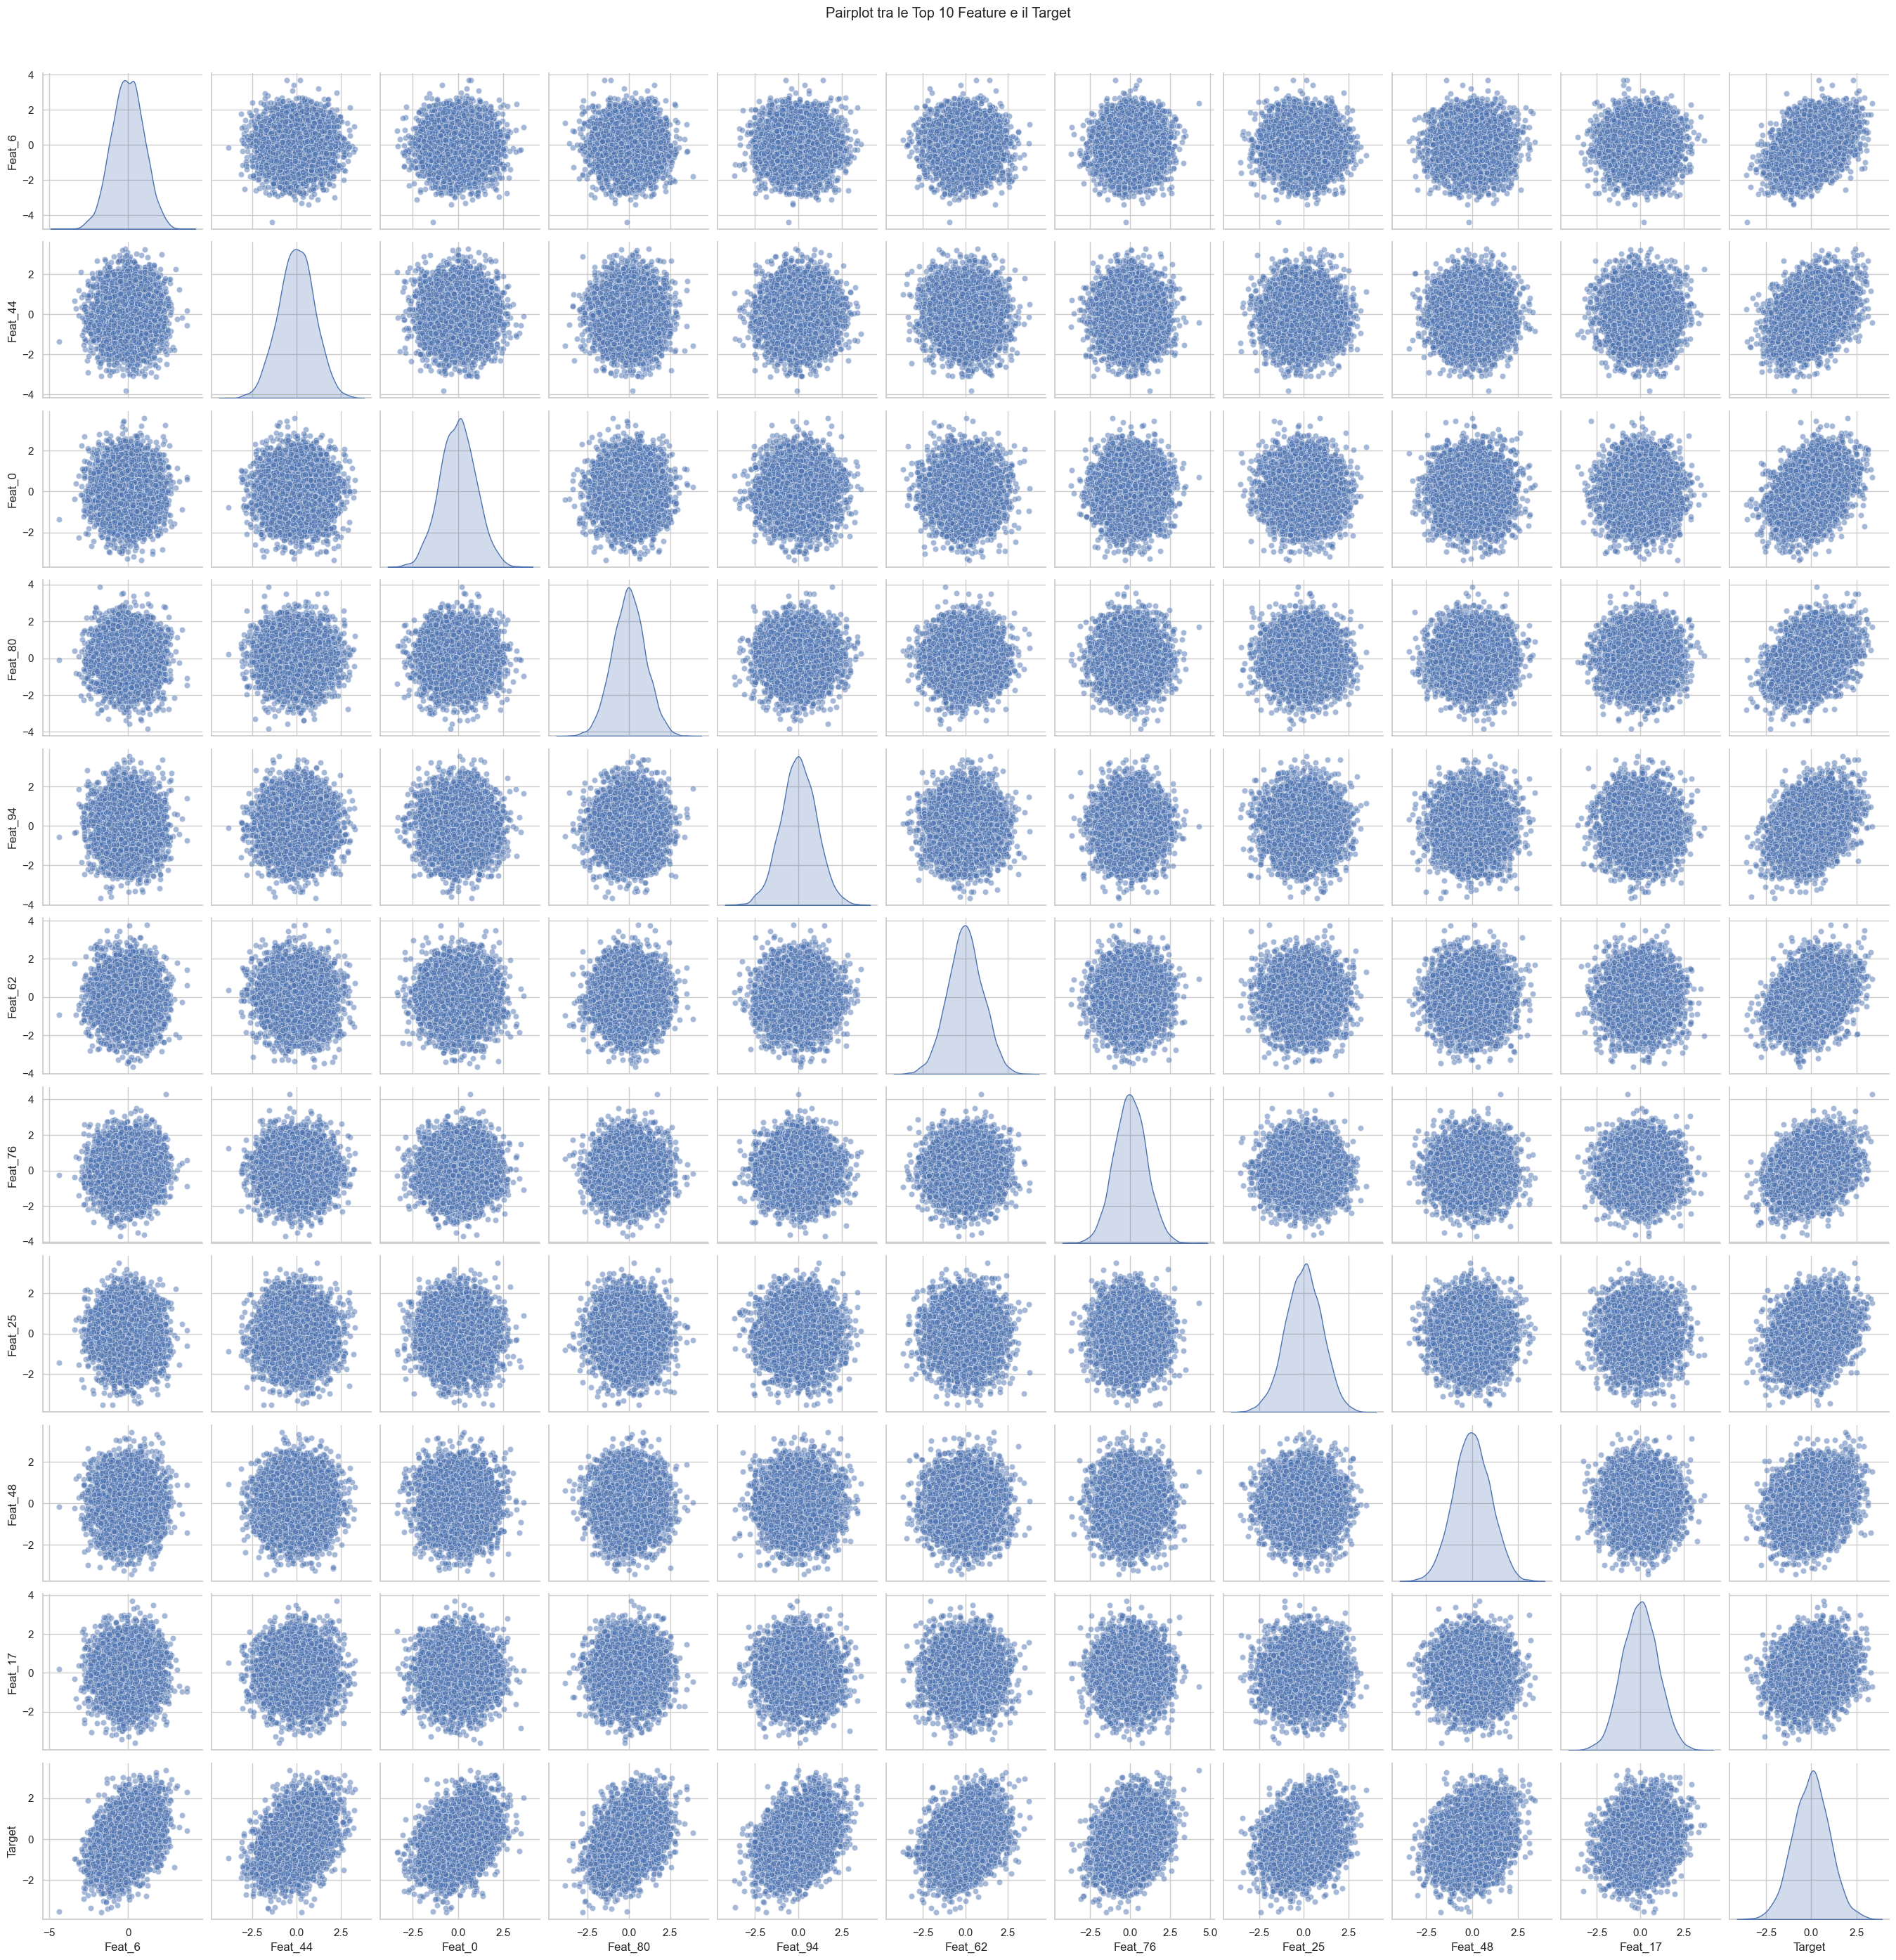

In [62]:
# PAIRPLOT
sns.pairplot(df[cols_to_plot], diag_kind='kde', plot_kws={'alpha': 0.5})
plt.suptitle(f"Pairplot tra le Top 10 Feature e il {target_col}", y=1.02)
plt.show()

3. PREPOCESSING E DATA SPLIT

In [63]:
#Standarizziamo i dati dividendo in Train (64%), Validation (16%) e Test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)   

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_val=scaler.transform(X_val)
X_test=scaler.transform(X_test)

print(f"Set di addestramento: {X_train.shape}")
print(f"Set di validazione: {X_val.shape}")
print(f"Set di test: {X_test.shape}")


Set di addestramento: (3840, 100)
Set di validazione: (960, 100)
Set di test: (1200, 100)


4. ARCHITETTURA DEI MODELLI

Il modello ROBUST utilizza:
- ELU Activation: per prevenire la morte dei neuroni
- Batch Normalization: per stabilizzare il gradiente
- L2 Regularization: per forzare i pesi delle feature inutili verso lo zero
- Dropout:  per prevenire la co-dipendenza dei neuroni

In [64]:
#definiamo un modello semplice sequenziale, con due layer nascosti interni, e un layer di output con un neurone (perchè è regressione) e senza attivazione (perchè stiamo prevedendo valori continui, non classi discrete)
def build_baseline_model():
    model=Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(1)
        ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

#definiamo un modello più robusto, con regolarizzazione L2, batch normalization e dropout, per prevenire l'overfitting e migliorare la generalizzazione del modello. iì
def build_robust_model():
    model=Sequential([
        Input(shape=(X_train.shape[1],)),
        
        Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(), #la batch normalization normalizza l'output di ogni layer, rendendo l'addestramento più stabile e veloce, e aiutando a prevenire l'overfitting
        Activation('relu'), #attiviamo il layer tramite layer
        Dropout(0.2), #ad ogni iterazione il 20% dei neuroni verranno spenti, questo aiuta a preevenire l'overfitting, perchè il modello non si affida troppo a pochi neuroni, ma impara a generalizzare meglio

        Dense(128, kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation('relu'),
        Dropout(0.1),

        Dense(1)
    ])
    #uso un learning rate iniziale controllato e basso per evitare di saltare il minimo globale, e poi lo riduco se il modello smette di miglioare
    optimizer=Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model    


5. TRAINING SESSION CON CALLBACKS STRATEGICI

Implementiamo EarlyStopping per fermarci al miglior punto di validazione a ReduceRonPlateau per sbloccare l'apprendimento quando la perdita stagna

In [65]:
#se per 15 addestramenti la val_loss non migliora, si stoppa e ci restituisce i valori migliori trovati 
callbacks=[
    EarlyStopping(monitor="val_loss",patience=15, restore_best_weights=True,verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1) #se per 5 addestramenti la val_loss non migliora, ridufce il learning rate di un fattore 0.5, fino a un minimo di 1e-6
]
print("Addestramento del modello baseline...")
model_b=build_baseline_model()
history_b=model_b.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64,verbose=0)

print("Addestramento del modello robusto...")
model_r=build_robust_model()
history_r=model_r.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=64, callbacks=callbacks)


Addestramento del modello baseline...
Addestramento del modello robusto...
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.7710 - mae: 0.6648 - val_loss: 0.2778 - val_mae: 0.3932 - learning_rate: 0.0010
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3655 - mae: 0.4587 - val_loss: 0.2064 - val_mae: 0.3246 - learning_rate: 0.0010
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2829 - mae: 0.3997 - val_loss: 0.1841 - val_mae: 0.3074 - learning_rate: 0.0010
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2316 - mae: 0.3546 - val_loss: 0.1395 - val_mae: 0.2584 - learning_rate: 0.0010
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1908 - mae: 0.3170 - val_loss: 0.1147 - val_mae: 0.2255 - learning_rate: 0.0010
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1681 - mae: 0.2952 - val_loss: 0.1104 - val_mae: 0.2228 - learning_rate: 0.0010
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1584 - mae: 0.283

6. CONFRONTO DELLE PERFORMANCE
Analizziamo le curve di apprendimento e calcoliamo l'errore finale sul Test Set

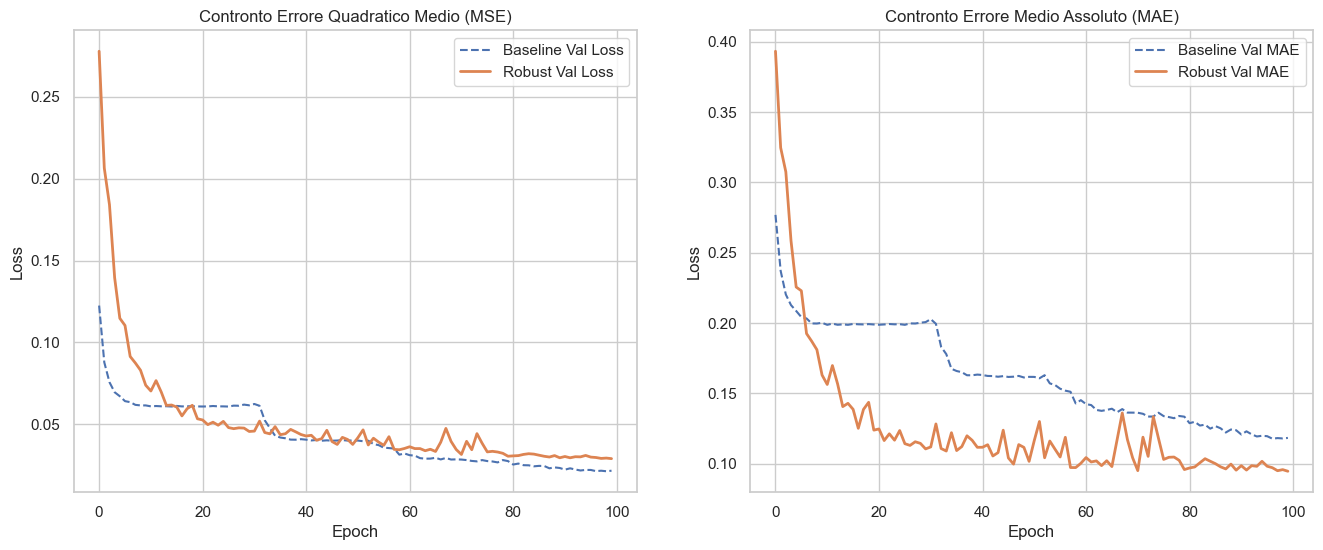

,Modello,MSE (Test),MAE (Test)
0,Baseline,0.019582,0.110758
1,Robust,0.028311,0.092459


In [66]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(16,6))

#Plot della loss
ax1.plot(history_b.history['val_loss'], label='Baseline Val Loss', linestyle='--')
ax1.plot(history_r.history['val_loss'], label='Robust Val Loss',linewidth=2)
ax1.set_title('Contronto Errore Quadratico Medio (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

#Plot MAE
ax2.plot(history_b.history['val_mae'], label='Baseline Val MAE',linestyle='--')
ax2.plot(history_r.history['val_mae'], label='Robust Val MAE',linewidth=2)
ax2.set_title('Contronto Errore Medio Assoluto (MAE)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

#Valutazione del modello
mse_b, mae_b=model_b.evaluate(X_test,y_test, verbose=0)
mse_r, mae_r=model_r.evaluate(X_test,y_test, verbose=0)

perf_df=pd.DataFrame({
    "Modello":["Baseline","Robust"],
    "MSE (Test)": [mse_b,mse_r],
    "MAE (Test)":[mae_b,mae_r]
})
display(perf_df)
